Agglomerative Clustering:
[0 0 0 1 1 1 2 2 2]


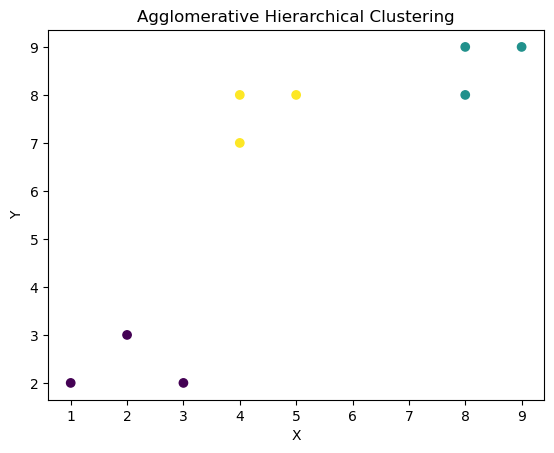

C:\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Divisive Clustering:
Cluster 1 : [[1 2]
 [2 3]
 [3 2]]
Cluster 2 : [[8 8]
 [9 9]
 [8 9]]
Cluster 3 : [[4 7]
 [5 8]
 [4 8]]


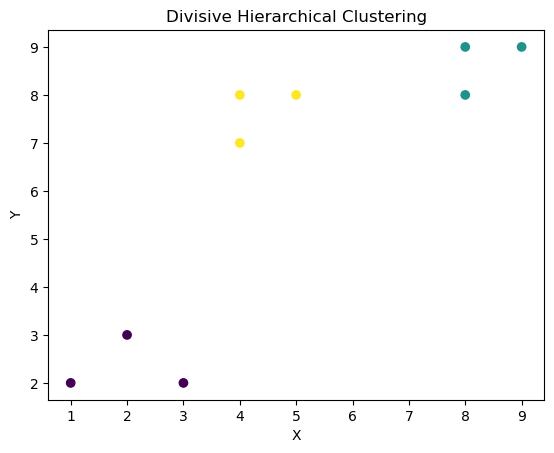

In [3]:
# Hierarchical Clustering
# Agglomerative and Divisive

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

# Sample data
X = np.array([
    [1, 2], [2, 3], [3, 2],
    [8, 8], [9, 9], [8, 9],
    [4, 7], [5, 8], [4, 8]
])

# -------------------------------
# 1. Agglomerative Clustering
# -------------------------------

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X)

print("Agglomerative Clustering:")
print(agg_labels)

plt.scatter(X[:, 0], X[:, 1], c=agg_labels)
plt.title("Agglomerative Hierarchical Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


# -------------------------------
# 2. Divisive Clustering
# -------------------------------

# Divisive clustering is implemented using
# recursive K-Means splitting.

def divisive_clustering(data, n_clusters):
    clusters = [data]

    while len(clusters) < n_clusters:
        # Select the largest cluster
        largest = max(clusters, key=len)
        clusters.remove(largest)

        # Split it into 2 clusters
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(largest)

        clusters.append(largest[labels == 0])
        clusters.append(largest[labels == 1])

    return clusters


clusters = divisive_clustering(X, 3)

print("\nDivisive Clustering:")

div_labels = np.zeros(len(X), dtype=int)

for i, cluster in enumerate(clusters):
    print("Cluster", i + 1, ":", cluster)

    for point in cluster:
        index = np.where(np.all(X == point, axis=1))[0][0]
        div_labels[index] = i

plt.scatter(X[:, 0], X[:, 1], c=div_labels)
plt.title("Divisive Hierarchical Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()